# Data Visualization

> "The simple graph has brought more information to the data analyst's mind than any other device." — John Tukey

In this lesson we use `seaborn` (built on `matplotlib`) to **answer questions with plots**. We will:

- visualize the **distribution** of a single variable,
- explore **relationships** between two (or more) variables, and
- preview how **faceting** splits a plot into small multiples for fair comparison.

**Learning objectives**

- Choose the right plot for categorical vs. numerical variables.
- Build scatterplots step by step and add a line of best fit when a trend matters.
- Compare a numerical variable across groups with box plots and overlapping density curves.
- Summarize two categorical variables with `pd.crosstab` and `sns.countplot` / `sns.barplot`.
- Preview faceting with `sns.relplot` as a bridge to the next lesson.

## Setup

We import pandas for the data, matplotlib for figures and axes, and seaborn for statistical plots. The pattern in this notebook is **object-oriented**:

- `fig, ax = plt.subplots(figsize=(width, height))` creates a blank figure and one axes; sizes are in **inches** (matplotlib default is about 6.4 × 4.8).
- Pass `ax=ax` into seaborn's axes-level functions (`countplot`, `histplot`, `scatterplot`, …).
- Set titles and labels on `ax` (`ax.set_title`, `ax.set_ylabel`) — not `plt.title`.

In [2]:
# pandas for tabular data: https://pandas.pydata.org/docs/
import pandas as pd

# matplotlib is the underlying plotting engine: https://matplotlib.org/stable/
import matplotlib.pyplot as plt

# seaborn is a high-level statistical plotting library: https://seaborn.pydata.org/
import seaborn as sns

# Apply seaborn's default theme (colors, fonts, grid) to every matplotlib figure.
sns.set_theme()

## The `penguins` dataset

seaborn ships with a few example datasets. `load_dataset("penguins")` returns the **Palmer Penguins** data as a pandas `DataFrame`: body measurements for penguins on three islands:

![](../assets/08/lter_penguins.png){height=300}

- `species` — the penguin's species (Adelie, Chinstrap, or Gentoo)
- `island` — the island where the penguin was observed
- `bill_length_mm`, `bill_depth_mm` — bill measurements, in millimeters
- `flipper_length_mm` — flipper length, in millimeters
- `body_mass_g` — body mass, in grams
- `sex` — the penguin's sex

A `DataFrame` is a rectangular table: **variables** live in columns and **observations** (here, individual penguins) live in rows.


In [3]:
# load_dataset downloads (and caches) a tidy example DataFrame.
penguins = sns.load_dataset("penguins")
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


`info()` is a quick way to see every column, its data type, and how many non-missing values it has. Notice that a few measurement columns have fewer than the total number of rows — those are **missing values**, which seaborn quietly drops when plotting.


In [4]:
# info() reports column names, dtypes, and non-null counts in one summary.
penguins.info()


<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


# One variable: distributions

How we picture the distribution of a *single* variable depends on whether it is **categorical** or **numerical**.

## A categorical variable

- A variable is **categorical** when it takes one of a small set of values, like `species`.
- A **count plot** ([`sns.countplot`](https://seaborn.pydata.org/generated/seaborn.countplot.html)) draws one bar per category; bar height is the number of observations in that category.
- With only one categorical variable on the plot, use **`order=`** to control left-to-right bar order on `x` (or bottom-to-top on `y`). There is no `hue`, so **`hue_order`** does not apply yet.

Text(0.5, 1.0, 'Number of penguins per species')

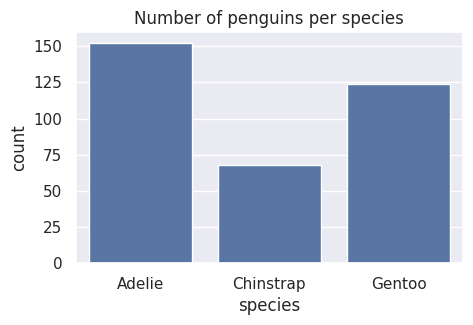

In [8]:
fig, ax = plt.subplots(
    figsize=(5, 3),   # (width, height) in inches — smaller than the matplotlib default
)

# countplot: one bar per species; height = number of penguins in that species.
sns.countplot(
    data=penguins,
    x="species",   # categorical column on the x-axis
    ax=ax,
)

ax.set_title("Number of penguins per species")

For categories with no natural order, sort bars by frequency:

- `value_counts()` counts each level and sorts high-to-low.
- Pass its `.index` to **`order=`** — the only ordering knob on a single-variable count plot.

In [10]:
# value_counts() returns counts sorted high-to-low; its index is the species order.
species_by_frequency = penguins["species"].value_counts().index
species_by_frequency

Index(['Adelie', 'Gentoo', 'Chinstrap'], dtype='str', name='species')

Text(0.5, 1.0, 'Penguins per species, ordered by frequency')

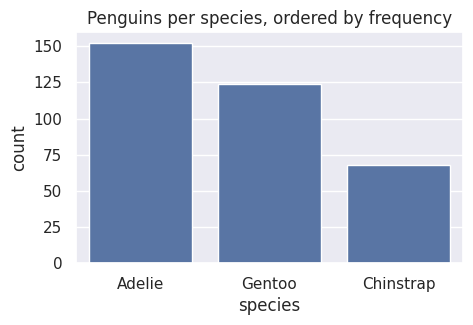

In [11]:
fig, ax = plt.subplots(
    figsize=(5, 3),
)

sns.countplot(
    data=penguins,
    x="species",
    order=species_by_frequency,   # order=: sequence of x-axis category labels
    ax=ax,
)

ax.set_title("Penguins per species, ordered by frequency")

## A numerical variable

A variable is **numerical** when it spans a range of numbers it makes sense to add or average, like `body_mass_g`.

A **histogram** splits the range into equal-width bins and draws a bar whose height is the number of observations in each bin.


Text(0.5, 1.0, 'Distribution of body mass')

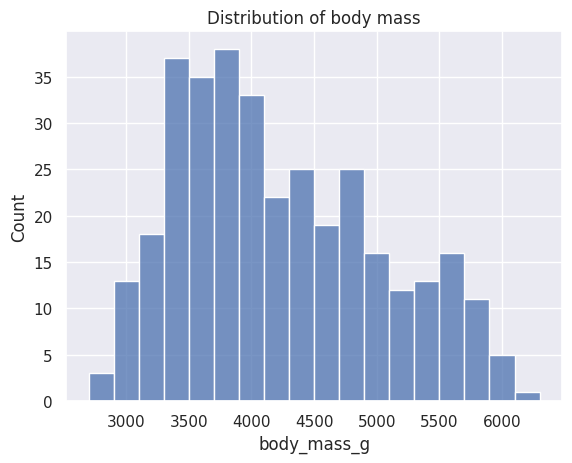

In [6]:
fig, ax = plt.subplots()

# histplot bins a numerical column; binwidth sets the width of each bin (in grams here).
sns.histplot(
    data=penguins,
    x="body_mass_g",
    binwidth=200,   # try other values: too small looks jagged, too large hides the shape
    ax=ax,
)

ax.set_title("Distribution of body mass")


Always try a few bin widths: too narrow makes a jagged chart, too wide hides the shape. A width of 200 g strikes a sensible balance and shows a single peak (unimodal) that trails off to the right (slightly right-skewed).

A **density (KDE) plot** is a smoothed alternative to the histogram. It is useful for continuous data and makes the overall shape — peaks and skew — easy to read at a glance.


Text(0.5, 1.0, 'Smoothed density of body mass')

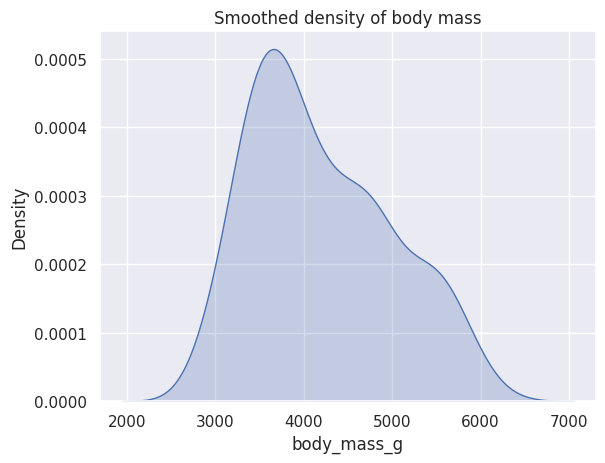

In [7]:
fig, ax = plt.subplots()

# kdeplot draws a smooth density curve; fill shades the area under it.
sns.kdeplot(
    data=penguins,
    x="body_mass_g",
    fill=True,
    ax=ax,
)

ax.set_title("Smoothed density of body mass")


# Relationships between two variables

To visualize a *relationship* we need at least two variables on the plot. Which plot to reach for depends on the **types** of the two variables:

- one numerical + one categorical,
- two categorical, or
- two numerical.

As before, each plot is chosen to answer a specific question.

## A numerical and a categorical variable

> Does body mass differ across penguin species?

A **box plot** summarizes a numerical variable for each category.

- Each box spans the **middle half of the data**
- the _line_ inside marks the **median**
- the _whiskers_ reach the bulk of the rest
- and _isolated points_ flag **possible outliers**


Text(0.5, 1.0, 'Body mass by species')

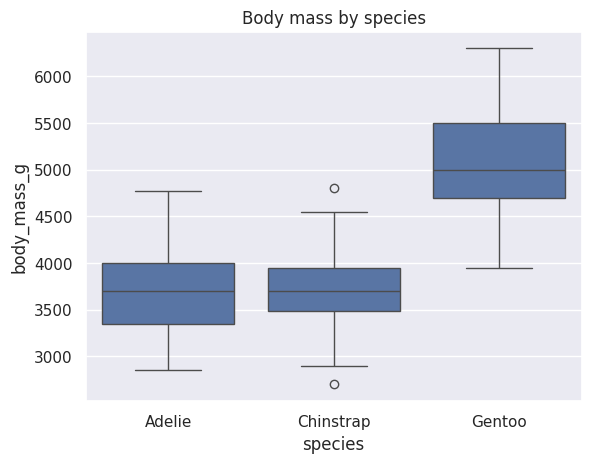

In [8]:
fig, ax = plt.subplots()

# boxplot: categorical x (species) vs numerical y (body mass), one box per species.
sns.boxplot(
    data=penguins,
    x="species",
    y="body_mass_g",
    ax=ax,
)

ax.set_title("Body mass by species")


The boxes show that Gentoo penguins are clearly heavier than Adelie and Chinstrap, whose distributions overlap a lot.

We can ask the same question with overlapping **density curves**, one per species. Mapping `species` to `hue` draws and colors a curve for each group; `fill` with some transparency makes the overlaps readable.


Text(0.5, 1.0, 'Body mass distribution by species')

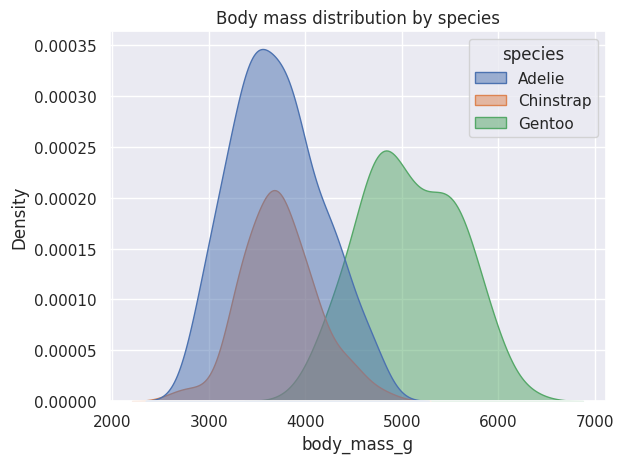

In [9]:
fig, ax = plt.subplots()

sns.kdeplot(
    data=penguins,
    x="body_mass_g",
    hue="species",   # one density curve per species, automatically colored
    fill=True,       # shade under each curve
    alpha=0.5,       # transparency so curves don't hide each other
    ax=ax,
)

ax.set_title("Body mass distribution by species")


## Two categorical variables

> How are the species distributed across the islands?

With two categorical variables we count how often each combination occurs:

- `pd.crosstab` builds a **wide** table of counts (islands × species) — handy to inspect in the notebook.
- [`sns.countplot`](https://seaborn.pydata.org/generated/seaborn.countplot.html) with `hue=` draws **dodged** bars: one group per `x` level, one bar per `hue` level inside each group.

### `order` and `hue_order`

When a plot maps two categorical variables, seaborn exposes **two** ordering parameters:

- **`order=`** — sequence of labels on the main axis (`x` here: island names left to right).
- **`hue_order=`** — sequence of `hue` levels (dodge order within each group + legend order).

If you omit either, seaborn infers level order from the data (often alphabetical).

In [10]:
# crosstab tallies how many penguins fall in each (island, species) combination.
island_species_counts = pd.crosstab(penguins["island"], penguins["species"])
island_species_counts


species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,124
Dream,56,68,0
Torgersen,52,0,0


In [ ]:
# order= controls island positions; hue_order= controls species dodge + legend.
island_order = penguins["island"].value_counts().index
species_order = sorted(penguins["species"].unique())

fig, ax = plt.subplots(
    figsize=(6, 3.5),   # a bit wider when hue= adds a legend and dodged bars
)

sns.countplot(
    data=penguins,
    x="island",
    hue="species",
    order=island_order,       # main axis: islands by sample size
    hue_order=species_order,  # hue axis: species labels (alphabetical here)
    ax=ax,
)

ax.set_title("Species counts per island")
ax.set_ylabel("count")

The raw counts are affected by the different number of penguins on each island. To compare the *composition* of each island:

- convert the crosstab to **proportions** with `normalize="index"` (each row sums to 1), then
- plot with [`sns.barplot`](https://seaborn.pydata.org/generated/seaborn.barplot.html) on pre-aggregated within-island percents.

Why not `countplot(..., stat="percent")`? That parameter normalizes bar heights so they sum to 100% **across the entire plot**, not within each island group — fine for a single breakdown, wrong for row-wise composition.

In [ ]:
# normalize="index" turns each row of counts into proportions that sum to 1.
island_species_proportions = pd.crosstab(
    penguins["island"],
    penguins["species"],
    normalize="index",
)

island_species_proportions

# Long-form percents: each island's rows sum to 100.
island_species_pct = (
    penguins.groupby(["island", "species"], observed=True)
    .size()
    .reset_index(name="count")
)
island_species_pct["percent"] = (
    island_species_pct.groupby("island")["count"]
    .transform(lambda n: 100 * n / n.sum())
)

island_order = penguins["island"].value_counts().index
species_order = sorted(penguins["species"].unique())

fig, ax = plt.subplots(
    figsize=(6, 3.5),   # match the count plot above for easy side-by-side comparison
)

# barplot reads heights from y=; order= / hue_order= work like countplot.
sns.barplot(
    data=island_species_pct,
    x="island",
    y="percent",
    hue="species",
    order=island_order,
    hue_order=species_order,
    ax=ax,
)

ax.set_title("Species proportions per island")
ax.set_ylabel("percent within island")

Now the story is clear: Gentoo penguins live only on Biscoe, Chinstrap only on Dream, and Adelie are found on all three islands (and are the only species on Torgersen).


## Two numerical variables

> Do penguins with longer flippers weigh more or less than penguins with shorter flippers?

Try to make your answer precise.

- Is the relationship positive or negative?
- Linear or curved?
- Strong or weak?
- Does it depend on the species?

A **scatterplot** of two numerical variables is the natural tool to find out. We map `flipper_length_mm` to the x-axis and `body_mass_g` to the y-axis.


Text(0.5, 1.0, 'Body mass vs. flipper length')

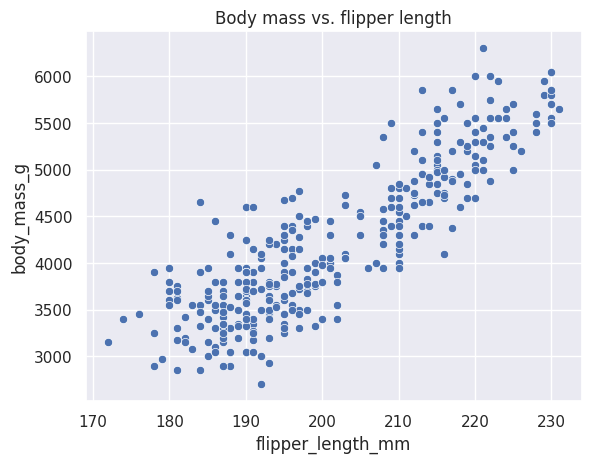

In [13]:
fig, ax = plt.subplots()

# scatterplot draws one point per penguin. data= is the DataFrame; x/y are column names.
sns.scatterplot(
    data=penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    ax=ax,
)

ax.set_title("Body mass vs. flipper length")


Already we can answer the motivating question:

- the relationship looks **positive** (longer flippers go with heavier penguins)
- **fairly linear** (points cluster around a straight line)
- **moderately strong** (not too much scatter)

It is always wise to be skeptical and ask whether a *third* variable changes the story. Does the relationship differ by species?

We can encode species with color by mapping it to the `hue` aesthetic. seaborn assigns one color per species automatically and adds a legend.


Text(0.5, 1.0, 'Body mass vs. flipper length, by species')

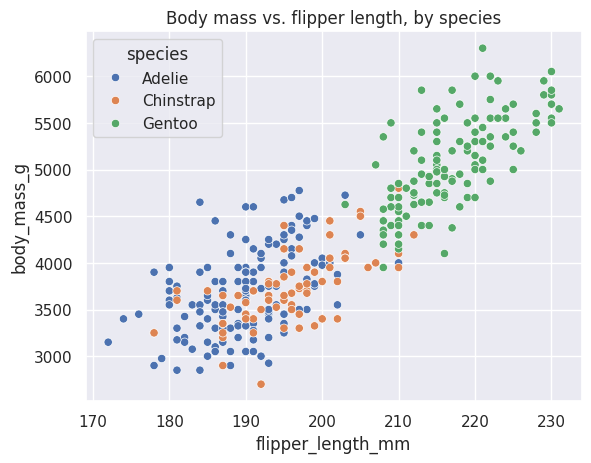

In [14]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",   # color each point by its species, and add a legend
    ax=ax,
)

ax.set_title("Body mass vs. flipper length, by species")


### Adding a line of best fit

To make the trend explicit we can overlay a **regression line** (a straight line fit through the points). `regplot` draws the scatter *and* a best-fit line with a shaded confidence band on the same Axes.


Text(0.5, 1.0, 'Body mass vs. flipper length with a line of best fit')

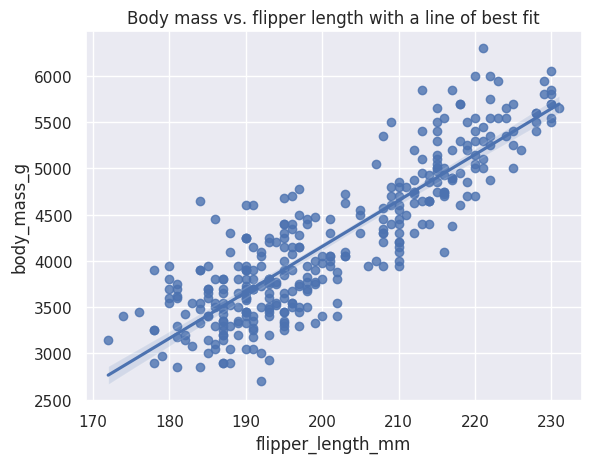

In [15]:
fig, ax = plt.subplots()

# regplot = scatter points + a fitted straight line (ordinary least squares).
sns.regplot(
    data=penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    ax=ax,
)

ax.set_title("Body mass vs. flipper length with a line of best fit")


The upward-sloping line confirms the positive relationship we saw by eye. The points hug the line reasonably closely, which is the visual signature of a *strong* linear relationship.


# Three or more variables: faceting (preview)

We can squeeze in a third variable by mapping it to `hue`, `style`, or `size` — but adding too many at once makes a plot hard to read.

A cleaner option for a categorical third variable is **faceting**: splitting the data into small side-by-side subplots — the same plot repeated for each subset, on the same scale. seaborn's figure-level `relplot` does this with `col=`.

This is only a preview. In `09_small_multiples.ipynb` you will learn how figure-level functions (`displot`, `relplot`, `catplot`) build faceted grids systematically.


Text(0.5, 1.02, 'Body mass vs. flipper length, faceted by island')

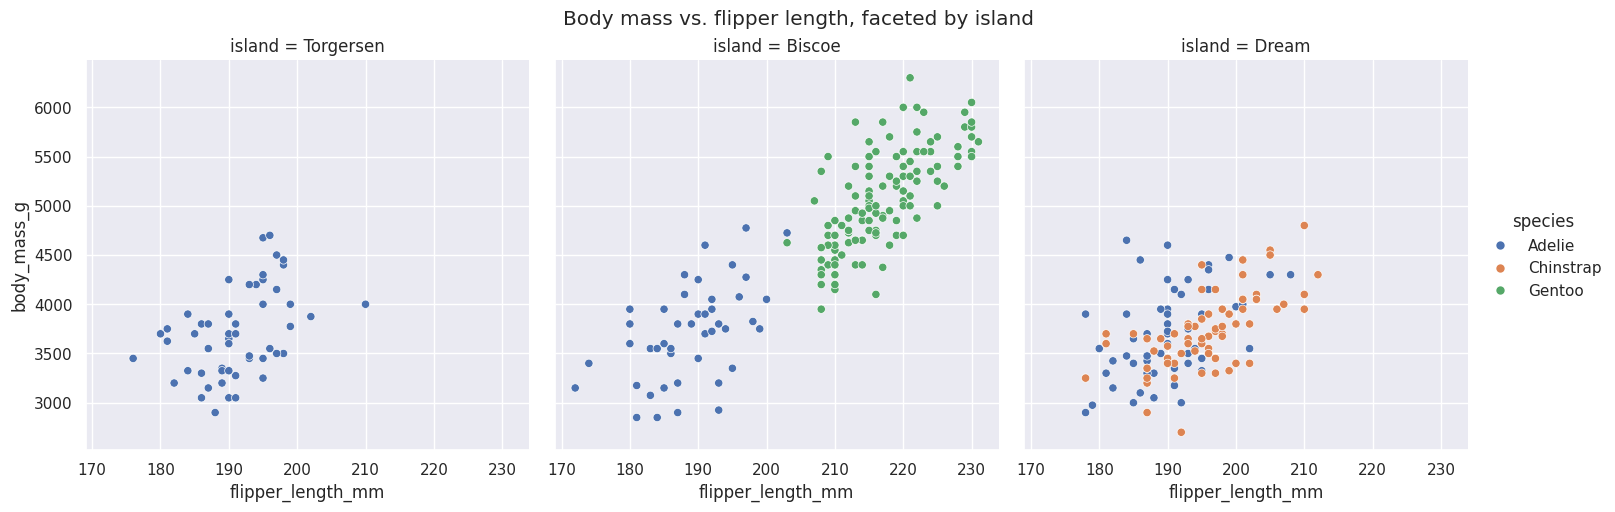

In [16]:
# relplot is figure-level: it manages its own grid of subplots, so we don't pass ax=.
grid = sns.relplot(
    data=penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",   # color points by species
    col="island",      # one subplot (facet) per island
    kind="scatter",
)

grid.figure.suptitle("Body mass vs. flipper length, faceted by island", y=1.02)


## Summary

| Variable Types                          | Visualization Technique                | Key Parameters/Notes                                                                                          |
|-----------------------------------------|----------------------------------------|--------------------------------------------------------------------------------------------------------------|
| Single categorical                      | `sns.countplot`                        | Use `order=` to sort bars by frequency.                                                                      |
| Two categoricals       | `sns.countplot` with `hue=`            | Set `order=` (main axis) and `hue_order=` (legend) to control grouping order.                                 |
| Single numerical                        | `sns.histplot`, `sns.kdeplot`          | Shows distribution shape with histogram or smoothed density plot.                                            |
| Numerical vs. categorical               | `sns.boxplot`, `sns.kdeplot` with `hue`| Compare numeric values across groups with box plots or overlapping densities.                                 |
| Two categorical (composition)           | `pd.crosstab`, `sns.barplot`           | Use `normalize="index"` for proportions in crosstab; `sns.barplot` on aggregated data for grouped percents.  |
| Two numerical                           | `sns.scatterplot`, `sns.regplot`       | Scatter for relationships; add `sns.regplot` for best-fit line. Map third variable to `hue` as needed.       |
| Three variables                         | Mapping: `hue`, `style`, `size`;       | Use these sparingly. For categorical third variable, use faceting: `sns.relplot(col=...)`.                   |

Next, in `09_small_multiples.ipynb`, you will learn how seaborn's **figure-level** functions turn faceting into a repeatable pattern for comparing distributions and relationships side by side.